In [63]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhrubangtalukdar/cybersecurity-threat-detection-dataset/cybersecurity.csv


# Step 1: Machine Learning Models

In [64]:
#Task 1.1
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/cybersecurity-threat-detection-dataset/cybersecurity.csv")

In [65]:
print("the first 5 rows:\n",df.head(),'\n')
print("the shape: \n",df.shape,'\n')
print("missing values: \n",df.isna().sum(),'\n')
print("class balance: \n",df["label"].value_counts(),'\n')

the first 5 rows:
              timestamp           src_ip           dst_ip  src_port  dst_port  \
0  2025-10-01 00:12:54   188.176.27.165  253.240.113.218     56377       445   
1  2025-10-01 00:23:43      68.59.26.43    212.75.38.111     51165      1433   
2  2025-10-01 00:25:46   119.204.243.78     90.28.90.234     14948      1433   
3  2025-10-01 00:27:21  122.119.194.175   175.140.78.230     36097       443   
4  2025-10-01 00:40:09   181.199.242.68     55.99.177.69       445     21255   

  protocol  bytes_sent  bytes_received  \
0      TCP        8029           17204   
1      TCP      676368         2643374   
2      TCP      316502           38571   
3      TCP       70933           21935   
4      TCP       12721            9939   

                                          user_agent  \
0  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
1  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
2  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
3  Mozilla/5.0 (Windows

**Class Balance**

The dataset is imbalanced, containing 9,600 benign samples (96%) and 400 attack samples (4%). Due to this class imbalance, **F1-score** is used as the primary evaluation metric instead of accuracy, as it provides a better measure of performance on the minority (attack) class.

In [66]:
df = df.drop(columns=["attack_type"])
df = df.drop(columns=["url"])

**Remove Attack Type Column**

The `attack_type` column was removed from the dataset because it directly reveals the type of attack, which could lead to data leakage and unrealistic model performance. Since the target variable is `label` (benign vs attack), this column is not used as a feature to ensure a fair and valid model evaluation.

**Remove URL Column**

The `url` column was removed from the dataset because it contains many missing values and is not considered an important feature for the model. This helps simplify the dataset and improve preprocessing efficiency.

In [67]:
#Task 1.2
X = df.drop(columns=["label"])
y=df["label"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_user = tfidf.fit_transform(X_train["user_agent"])
X_test_user = tfidf.transform(X_test["user_agent"])

The `user_agent` column was converted into numerical features using TF-IDF. The vectorizer was fitted on the training data only and then applied to the test data to avoid data leakage.

In [69]:
from sklearn.preprocessing import OneHotEncoder

onehot= OneHotEncoder(handle_unknown="ignore", sparse_output=True)

X_train_protocol = onehot.fit_transform(X_train[["protocol"]])
X_test_protocol = onehot.transform(X_test[["protocol"]])

The `protocol` column was converted into numerical format using One-Hot Encoding. The encoder was fitted on the training set only and then applied to the test set to prevent data leakage. The `handle_unknown="ignore"` option ensures that unseen categories in the test set are handled safely.

In [70]:
X_train_num = X_train[["src_port", "dst_port", "bytes_sent", "bytes_received"]]
X_test_num = X_test[["src_port", "dst_port", "bytes_sent", "bytes_received"]]

In [71]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_num, X_train_protocol, X_train_user])
X_test_final = hstack([X_test_num, X_test_protocol, X_test_user])

All processed numerical, categorical, and text features were combined into a single feature matrix using `hstack` before training the model.

In [72]:
#Task 1.3

#LogisticRegression
from sklearn.linear_model import LogisticRegression
model_logistic = LogisticRegression()
model_logistic.fit(X_train_final, y_train)

#RandomForest
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier()
modelRF.fit(X_train_final, y_train)

#KNN
from sklearn.neighbors import KNeighborsClassifier
modelKNN = KNeighborsClassifier()
modelKNN.fit(X_train_final, y_train)

KNeighborsClassifier()

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#LogisticRegression 
y_pred1 = model_logistic.predict(X_test_final)
print("===========logistic regression============")
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1-score:", f1_score(y_test, y_pred1))

#Random Forest
y_pred2 = modelRF.predict(X_test_final)
print("=============Random Forest================")
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1-score:", f1_score(y_test, y_pred2))

#KNN
y_pred3 = modelKNN.predict(X_test_final)
print("====================KNN====================")
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))
print("Recall:", recall_score(y_test, y_pred3))
print("F1-score:", f1_score(y_test, y_pred3))

===========logistic regression============
Accuracy: 0.961
Precision: 1.0
Recall: 0.025
F1-score: 0.04878048780487805
=============Random Forest================
Accuracy: 0.966
Precision: 0.8333333333333334
Recall: 0.1875
F1-score: 0.30612244897959184
====================KNN====================
Accuracy: 0.9595
Precision: 0.4
Recall: 0.025
F1-score: 0.047058823529411764


In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

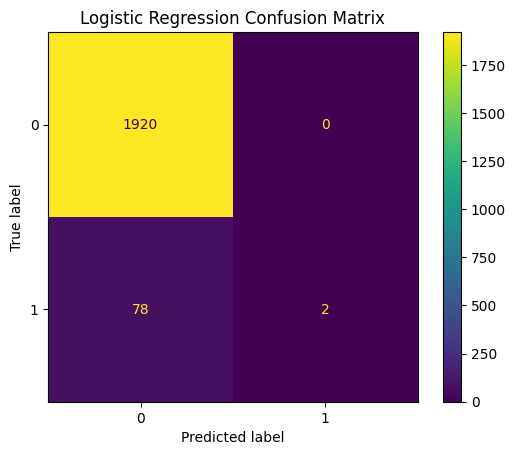

In [75]:
#LogisticRwgression
cm1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)

disp1.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

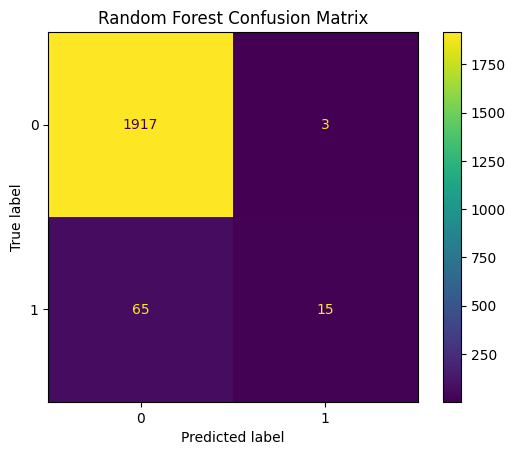

In [76]:
#RandomForest 
cm2 = confusion_matrix(y_test, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)

disp2.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

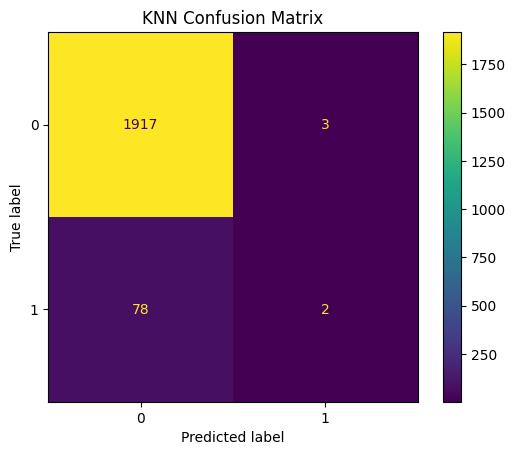

In [77]:
#KNN
cm3 = confusion_matrix(y_test, y_pred3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)

disp3.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [78]:
#============Summmary===============
print("Model:", model_logistic)
print("Accuracy:", accuracy_score(y_test, y_pred1))
print("F1-score:", f1_score(y_test, y_pred1))
print("-------------------------------------------")
print("Model:", modelRF)
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("F1-score:", f1_score(y_test, y_pred2))
print("-------------------------------------------")
print("Model:", modelKNN)
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("F1-score:", f1_score(y_test, y_pred3))

Model: LogisticRegression()
Accuracy: 0.961
F1-score: 0.04878048780487805
-------------------------------------------
Model: RandomForestClassifier()
Accuracy: 0.966
F1-score: 0.30612244897959184
-------------------------------------------
Model: KNeighborsClassifier()
Accuracy: 0.9595
F1-score: 0.047058823529411764


**Best Model Selection**

**Random Forest** is the best performing model overall. Although all models achieved high accuracy due to class imbalance, Random Forest achieved the highest F1-score (0.30) and the best recall (0.1875), meaning it is more effective at detecting attack cases compared to Logistic Regression and KNN.